# Decision Tree and CART


## What Is Decision Tree Regression?

<span style="color:#1f77b4">**Decision Tree Regression**</span> models the target variable by learning simple decision rules inferred from data features.

It's a <span style="color:#1f77b4">**non-parametric**</span> method that splits the <span style="color:#ff7f0e">**input space into regions**</span> with approximately constant values.

---

### How It Works

- The algorithm recursively splits the dataset into subsets to minimize the <span style="color:#2ca02c">**mean squared error (MSE)**</span>.
- At each node, it selects the <span style="color:#ff7f0e">**best feature and split point**</span> that minimizes MSE.
- The tree continues growing until stopping criteria are met (e.g., max depth or min samples per leaf).

---

### Pros and Cons

- Easy to understand and visualize  
- Handles nonlinear relationships well  
- Requires little preprocessing (no scaling)

- Prone to <span style="color:#ff7f0e">**overfitting**</span>  
- Sensitive to small data changes  
- No smooth predictions (piecewise constant)

> In this note, we will re-examine decision tree, using classification as an example

## Classification And Regression Tree (CART)


<span style="color:#1f77b4">**CART**</span> stands for **C**lassification **A**nd **R**egression **T**ree introduced by Breiman, Friedman, Olshen & Stone (1984). It builds a binary decision tree by <span style="color:#ff7f0e">**recursively partitioning**</span> the feature space into <span style="color:#1f77b4">**rectangular regions**</span> that are as <span style="color:#2ca02c">**“pure”**</span> as possible with respect to the target variable. The visualization below shows how <span style="color:#ff7f0e">**one split**</span> creates two regions, then additional splits carve the same 2D feature space into more <span style="color:#1f77b4">**rectangular leaves**</span>.

**Core ingredients**

* <span style="color:#ff7f0e">**Impurity metric**</span>: 
    - Gini impurity 
        $$1 - \sum_{j=1}^K p_j^2$$
    - cross-entropy 
        $$H(T)=- \frac{1}{n}\sum_{j=1}^K \sum_{i=1}^n {1}[y_i = j] p_j(X_i)$$

* Split search: Evaluate every feature and every possible split point; choose the split that yields the <span style="color:#2ca02c">**largest impurity reduction**</span> 
* <span style="color:#ff7f0e">**Stopping rules**</span>
    -  Maximum depth
    - Minimum impurity decrease
    -  `min_samples_split` / `min_samples_leaf`
    - Maximum number of leaves (`max_leaf_nodes`)    

> Q: What is the metric used for regression tree?

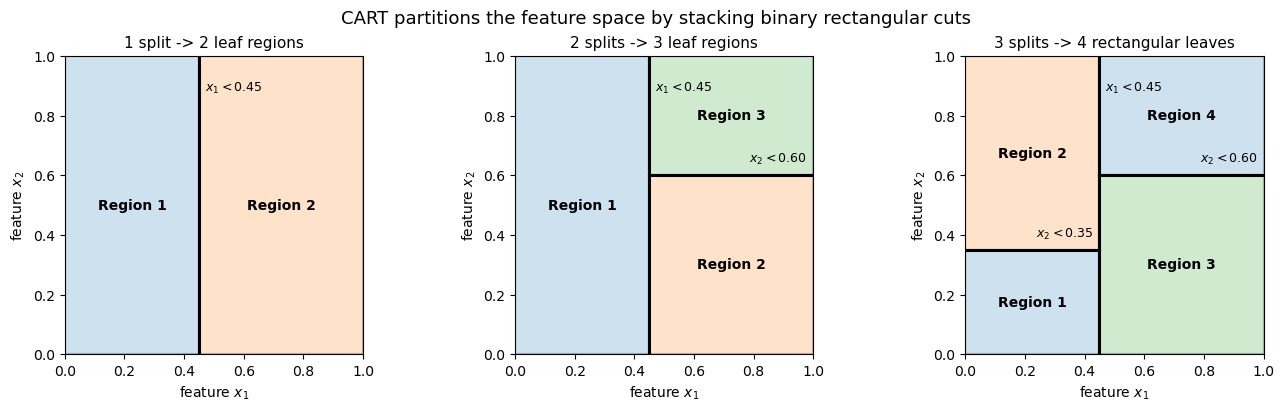

In [1]:
# Visualize how CART recursively partitions a 2D feature space.
# Each panel shows the terminal regions after a few binary, axis-aligned splits.

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4), constrained_layout=True)
region_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#1f77b4"]

panels = [
    {
        "title": "1 split -> 2 leaf regions",
        "regions": [
            (0.00, 0.00, 0.45, 1.00, "Region 1"),
            (0.45, 0.00, 0.55, 1.00, "Region 2"),
        ],
        "lines": [("v", 0.45, 0.00, 1.00, r"$x_1 < 0.45$")],
    },
    {
        "title": "2 splits -> 3 leaf regions",
        "regions": [
            (0.00, 0.00, 0.45, 1.00, "Region 1"),
            (0.45, 0.00, 0.55, 0.60, "Region 2"),
            (0.45, 0.60, 0.55, 0.40, "Region 3"),
        ],
        "lines": [
            ("v", 0.45, 0.00, 1.00, r"$x_1 < 0.45$"),
            ("h", 0.60, 0.45, 1.00, r"$x_2 < 0.60$"),
        ],
    },
    {
        "title": "3 splits -> 4 rectangular leaves",
        "regions": [
            (0.00, 0.00, 0.45, 0.35, "Region 1"),
            (0.00, 0.35, 0.45, 0.65, "Region 2"),
            (0.45, 0.00, 0.55, 0.60, "Region 3"),
            (0.45, 0.60, 0.55, 0.40, "Region 4"),
        ],
        "lines": [
            ("v", 0.45, 0.00, 1.00, r"$x_1 < 0.45$"),
            ("h", 0.60, 0.45, 1.00, r"$x_2 < 0.60$"),
            ("h", 0.35, 0.00, 0.45, r"$x_2 < 0.35$"),
        ],
    },
]

for ax, panel in zip(axes, panels):
    for i, (x, y, width, height, label) in enumerate(panel["regions"]):
        ax.add_patch(
            Rectangle(
                (x, y), width, height,
                facecolor=region_colors[i],
                edgecolor="black",
                linewidth=1.6,
                alpha=0.22,
            )
        )
        ax.text(
            x + width / 2, y + height / 2, label,
            ha="center", va="center", fontsize=10, weight="bold",
        )

    for orientation, value, start, end, label in panel["lines"]:
        if orientation == "v":
            ax.plot([value, value], [start, end], color="black", linewidth=2.2)
            ax.text(value + 0.02, end - 0.08, label, fontsize=9, ha="left", va="top")
        else:
            ax.plot([start, end], [value, value], color="black", linewidth=2.2)
            ax.text(end - 0.02, value + 0.03, label, fontsize=9, ha="right", va="bottom")

    ax.set_title(panel["title"], fontsize=11)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel(r"feature $x_1$")
    ax.set_ylabel(r"feature $x_2$")
    ax.set_aspect("equal")
    ax.grid(False)

fig.suptitle("CART partitions the feature space by stacking binary rectangular cuts", fontsize=13)
plt.show()


> *A decision tree finds clarity by asking one question at a time; its strength lies in choosing the right questions, and its wisdom in knowing when another branch would only memorize the noise.* --— Words of wisdom by GPT-5.6 Pro (2026)

> *A decision tree gets smart the way people do: one blunt yes-or-no question at a time, never looking back --- and its real wisdom is knowing when to stop asking.* --- Words of wisdom by Claude Fable 5 (2026)



> Check out the (much better) visualization by MLU:  https://mlu-explain.github.io/decision-tree/

In [2]:
# --- Synthetic data: three classes separated by two straight lines -------
# The "truth" is known, so we can see exactly how well CART recovers it.
# Note both true boundaries are OBLIQUE lines; CART can only cut
# perpendicular to one axis at a time (Steps 2-3 of the algorithm below),
# so it must approximate them with rectangles.

import numpy as np                       # for arrays and random number generation

sample_size = 20  # Number of data points
rng = np.random.default_rng(0)           # fixed seed: everyone gets the same data
X = rng.uniform(0.1, 0.9, size=(sample_size, 2))   # 20 points, 2 features
y = np.zeros(sample_size, dtype=int)
mask1 = X[:, 0] + X[:, 1] > 1.1          # above the line x1 + x2 = 1.1 -> class 1
mask2 = (~mask1) & (X[:, 0] - X[:, 1] > 0.3)   # below it, right of x1 - x2 = 0.3 -> class 0
y[mask1] = 1
y[mask2] = 0
y[~(mask1 | mask2)] = 2                  # everything else -> class 2


> Q: Can you draw the feature space segmented by the true label $y$ on your notebook?  
>   Terminologies: decision region, decision boundary


In [3]:
# Fit CART. See the "Example Algorithm: top-down greedy growth" cell below;
# Steps 1-4 all happen inside .fit():
#   Step 1 (start):   all 20 points enter the root node.
#   Step 2 (search):  every feature and every candidate split value is
#                     scored by impurity reduction (criterion='gini' default).
#   Step 3 (pick):    the best split is kept -- greedy, no revisiting.
#   Step 4 (recurse + stop): children are split in turn until the stopping
#                     rule triggers (here: max_leaf_nodes = k).
# Step 5 (predict):   each leaf is labeled by its majority class;
#                     .predict() routes a point to its leaf, returns that label.

from sklearn.tree import DecisionTreeClassifier
k=4
clf = DecisionTreeClassifier(max_leaf_nodes=k, random_state=0).fit(X, y)

[Text(0.5, 0.8333333333333334, 'x[1] <= 0.486\ngini = 0.615\nsamples = 20\nvalue = [3, 9, 8]'),
 Text(0.25, 0.5, 'x[0] <= 0.667\ngini = 0.512\nsamples = 11\nvalue = [3, 1, 7]'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'gini = 0.0\nsamples = 7\nvalue = [0, 0, 7]'),
 Text(0.375, 0.16666666666666666, 'gini = 0.375\nsamples = 4\nvalue = [3, 1, 0]'),
 Text(0.75, 0.5, 'x[0] <= 0.348\ngini = 0.198\nsamples = 9\nvalue = [0, 8, 1]'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.875, 0.16666666666666666, 'gini = 0.0\nsamples = 8\nvalue = [0, 8, 0]')]

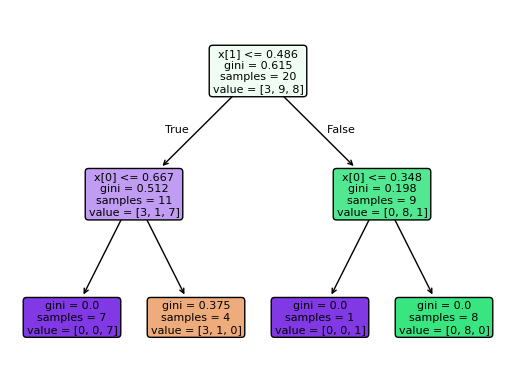

In [4]:
# Visualize the fitted tree: each internal node shows the split chosen in
# Steps 2-3 (one feature, one threshold), each leaf shows the class counts
# behind its majority-class prediction (Step 5).
from sklearn.tree import plot_tree
plot_tree(clf, filled=True, rounded=True, fontsize=8)

In [5]:
# --- Interactive: grow the tree one leaf at a time --------------------------
# The slider sets K = max_leaf_nodes, the stopping rule of Step 4: larger K
# lets the greedy growth (Steps 2-4) run longer, carving the feature space
# into more axis-aligned rectangles.

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import ipywidgets as widgets                     # slider, output area, VBox
from IPython.display import display              # to display the VBox
from sklearn.tree import DecisionTreeClassifier, plot_tree

label_cmap = ListedColormap(["#1f77b4", "#ff7f0e", "#2ca02c"])

k_slider = widgets.IntSlider(value=3, min=2, max=10, step=1,
                             description="# of leafs (K):", continuous_update=False)

out = widgets.Output()

def redraw(k):
    out.clear_output(wait=True)
    clf = DecisionTreeClassifier(max_leaf_nodes=k, random_state=0).fit(X, y)   # Steps 1-4 rerun with the new stopping rule

    xx, yy = np.meshgrid(np.linspace(0, 1, 300),
                         np.linspace(0, 1, 300))
    leaf_id = clf.apply(np.c_[xx.ravel(), yy.ravel()])   # which leaf (rectangle) each grid point lands in
    uniq = np.unique(leaf_id)
    mapper = {lid: i for i, lid in enumerate(uniq)}
    zz = np.vectorize(mapper.get)(leaf_id).reshape(xx.shape)
    region_cmap = ListedColormap(plt.cm.Paired.colors[:len(uniq)])

    with out:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))

        # left: decision regions + data
        axes[0].contourf(xx, yy, zz, alpha=0.25, cmap=region_cmap)
        axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap=label_cmap,
                        edgecolor="k", s=100)
        axes[0].set(xlabel="$x_1$", ylabel="$x_2$",
                    xlim=(0, 1), ylim=(0, 1),
                    title=f"Decision regions (K = {k})")
        axes[0].grid(alpha=0.3)

        # right: tree diagram
        plot_tree(clf, ax=axes[1], impurity=False,
                  filled=True, rounded=True, fontsize=8)
        axes[1].set_title("Tree structure")

        plt.tight_layout()
        plt.show()

redraw(k_slider.value)
k_slider.observe(lambda c: redraw(c["new"]), names="value")

# --- display: plots first, slider underneath ---------------------
display(widgets.VBox([out, k_slider]))


 
**Example Algorithm: top-down “greedy” growth**

1. **Start** with all training data in the root node.
2. **For each candidate feature & split value**

   * Compute impurity reduction.
3. **Pick the best split.**
4. **Recurse** on each child node until a stopping rule triggers.
5. **Assign a prediction** to every terminal (leaf) node

   * Classification: majority class (or class probabilities).
   * Regression: mean (or median) target value.

> Greedy means each split is *locally* optimal; the algorithm does **not** revisit earlier splits.

### Pruning 

Decision trees tend to *overfit* the training data. CART combats this by **cost-complexity pruning**:

1. Build the **maximal tree** (until every leaf is pure or stops).
2. Generate a sequence of *nested pruned trees* $T_0 \supset T_1 \supset \ldots \supset T_k$ by iteratively removing the branch that produces the **smallest increase** in

   $$
   R_\alpha(T) = \text{Total error}(T) + \alpha \times |T_\text{leaves}|
   $$

   where $\alpha$ penalizes complexity.
3. Select the subtree with the lowest **cross-validated error**.

> Q: What does overfitting mean?  
> Note: Cross-validation will be discussed in model evaluation. 